In [1]:
# Repo-root bootstrap: makes source/ importable and data/models paths absolute
# regardless of where the notebook server was started.
import sys
import pathlib

try:
    ROOT = pathlib.Path(__file__).resolve().parents[2]
except NameError:  # __file__ not defined in some environments (e.g. Jupyter console)
    ROOT = pathlib.Path.cwd()
    while not (ROOT / 'source').exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))


In [2]:
from source.ion_channel import IonChannel
from source.patch_clamp import PatchClamp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from source.moreka import AxonData
import plotly.express as px
import plotly.graph_objects as go


2026-09-15 15:35:46.136235: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-15 15:35:46.163593: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-15 15:35:46.163622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-15 15:35:46.164446: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-15 15:35:46.168924: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-15 15:35:46.169425: I tensorflow/core/platform/cpu_feature_guard.cc:1

2026-09-15 15:35:46.876186: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Load some data

(5994,)


<Axes: xlabel='time', ylabel='signal'>

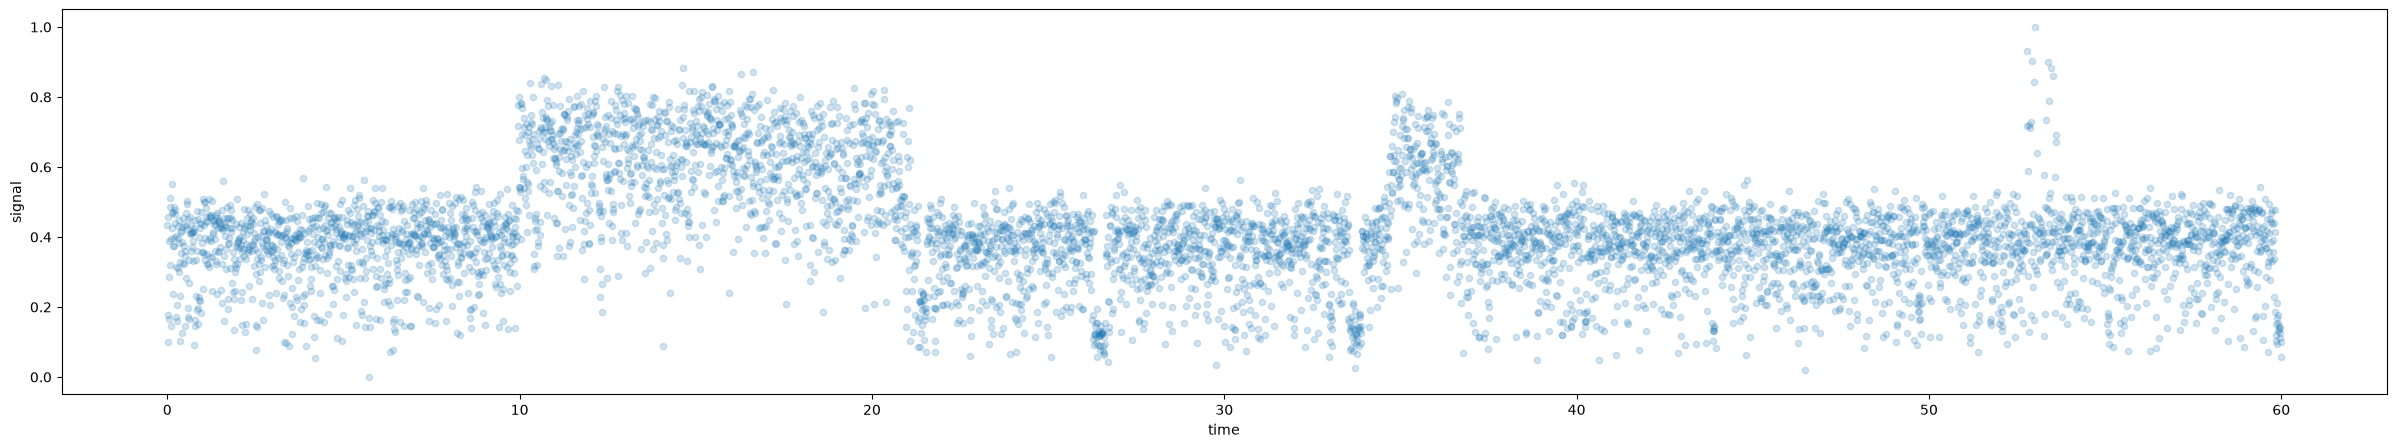

In [3]:
data = AxonData(dirname=str(ROOT / 'data' / 'raw'))
df = data[3].iloc[::100, :]

# remove outliers in signal
df = df[np.abs(df.signal - df.signal.mean()) <= (4 * df.signal.std())]
# all signals must be positive
df = df[df.signal > 0]

# normalize signal to be between 0 and 1
df.signal = (df.signal - np.min(df.signal)) / (np.max(df.signal) - np.min(df.signal))

X = df.signal.values
print(X.shape)
df.plot(x='time', y='signal', figsize=(30, 5), kind='scatter', alpha=0.2)


In [4]:
def prepare_test_data(X, y, x_len=50, y_len=1):
    X_lstm = []
    y_lstm = []
    for i in range(len(X)):
        for j in range(x_len, len(X[i]) - x_len):
            idx = i
            # randomly select a point in X[idx] which its index is greater than x_len and smaller than len(X[idx]) - x_len
            y_index = j
            y_lstm.append(y[idx][y_index:y_index + y_len])
            # x is the previous x_len points of y and x_len points after y, excluding y
            x_before = X[idx][y_index - x_len:y_index]
            x_after = X[idx][y_index + 1:y_index + x_len + 1]
            X_lstm.append(np.stack([np.concatenate((x_before, x_after))]))
            
    return np.array(X_lstm), np.array(y_lstm)

In [5]:
X_lstm, y_lstm = prepare_test_data([X], [X])
print(X_lstm.shape)
print(y_lstm.shape)

(5894, 1, 100)
(5894, 1)


In [6]:
# load model and predict
model = keras.models.load_model(str(ROOT / 'code' / '04_ml' / 'models/LSTM_normalized_50_50_artificial_data.keras'))

2026-09-15 15:35:48.630729: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-15 15:35:48.636318: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
y_pred = model.predict(X_lstm.reshape(-1, 100))
y_pred = np.argmax(y_pred, axis=1)

  1/185 [..............................] - ETA: 1:10

  5/185 [..............................] - ETA: 2s  

 11/185 [>.............................] - ETA: 1s

 16/185 [=>............................] - ETA: 1s

 22/185 [==>...........................] - ETA: 1s

...

168/185 [==========================>...] - ETA: 0s

174/185 [===========================>..] - ETA: 0s

180/185 [============================>.] - ETA: 0s

185/185 [==============================] - ETA: 0s

185/185 [==============================] - 2s 10ms/step


(200.0, 600.0)

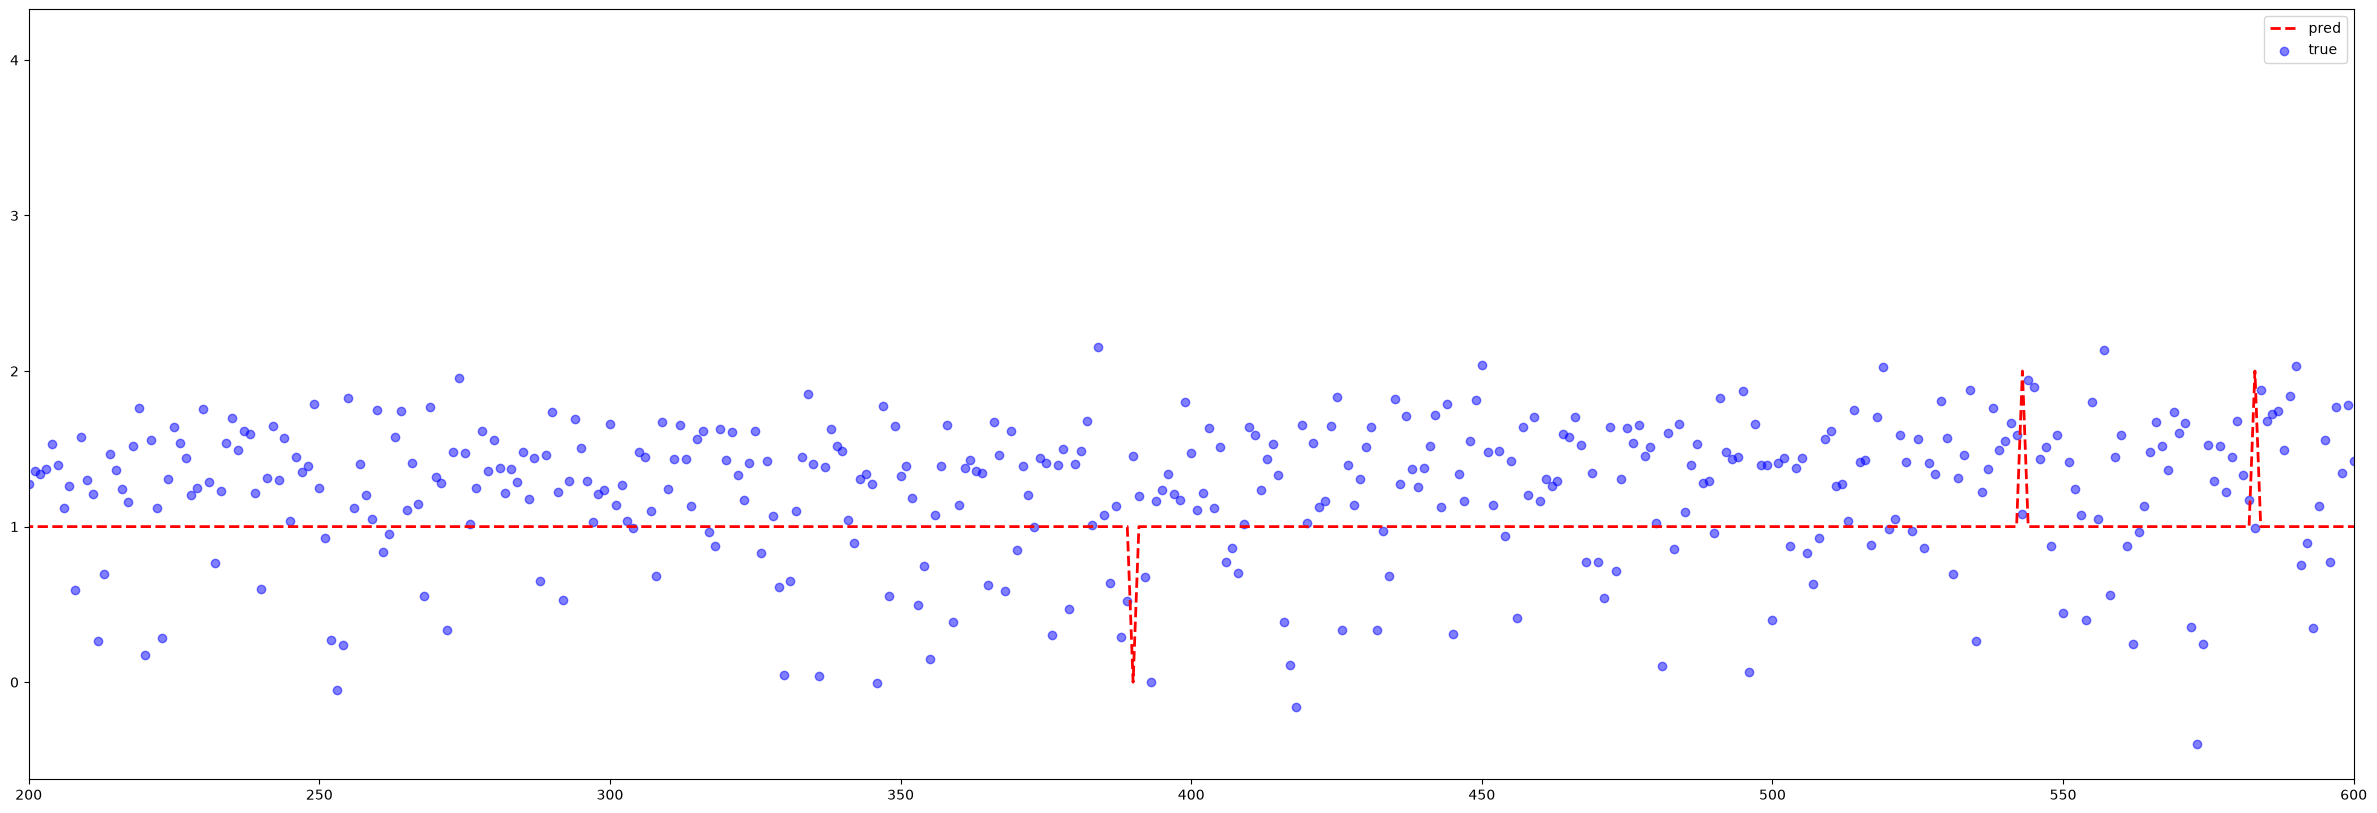

In [8]:
plt.figure(figsize=(30, 10))

# start from 50
plt.plot(range(50, 50 + len(y_pred)), y_pred, color='red', label='pred', linestyle='dashed', linewidth=2)
# X_test_ion scatter plot
plt.scatter(range(len(X)), X * 4.5 - 0.4, color='blue', label='true', alpha=0.5)
plt.legend()
plt.xlim(200, 600)

In [9]:

# Assuming y_pred and X are your data
x = np.arange(50, 50 + len(y_pred))
fig = px.line(x=x, y=y_pred, color_discrete_sequence=['red'], labels={'x': '', 'y': 'pred'})
fig.add_trace(go.Scatter(x=np.arange(len(X)), y=X * 4.5 - 0.4, mode='markers', marker_color='blue', marker_opacity=0.5, name='true'))
# fig.update_layout(legend_title_text='', width=1200, height=400, xaxis_range=[200, 600])
fig.show()